## GOES data processing - 7 day Baseline (2020 Day 210 - 217) ##

In [1]:
!pip install xarray zarr gcsfs cftime nc-time-axis s3fs fsspec netCDF4 pandas matplotlib dask 

In [2]:
import datetime as dt
import xarray as xr
import s3fs
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
def get_goes_files(year, day_of_year, product="ABI-L2-SSTF", sat="goes-east"):
    fs = s3fs.S3FileSystem(anon=True)

    bucket = "noaa-goes16" if sat == "goes-east" else "noaa-goes17"
    syr = str(year).zfill(4)
    sjdy = str(day_of_year).zfill(3)

    files = fs.glob(f"s3://{bucket}/{product}/{syr}/{sjdy}/*/*.nc")
    return fs, files

In [11]:
def get_single_goes_file(
    sat="goes-east",
    year=2020,
    day_of_year=210,
    product="ABI-L2-SSTF"
):

    fs = s3fs.S3FileSystem(anon=True)

    syr = str(year).zfill(4)
    sjdy = str(day_of_year).zfill(3)

    bucket = "noaa-goes16"

    files = fs.glob(
        f"s3://{bucket}/{product}/{syr}/{sjdy}/*/*.nc"
    )

    print("Files found:", len(files))

    file = files[0]

    print("Opening:", file)

    with fs.open(file) as f:
        ds = xr.open_dataset(
            f,
            engine="h5netcdf"
        )

    return ds

In [12]:
def process_goes_days(year, days, max_files_per_day=4):
    rows = []

    for day in days:
        fs, files = get_goes_files(year, day)

        print(f"Day {day}: found {len(files)} files")

        selected_files = files[::max(1, len(files)//max_files_per_day)][:max_files_per_day]

        for file in selected_files:
            print("Processing:", file)
            try:
                row = process_one_goes_file(fs, file)
                rows.append(row)
            except Exception as e:
                print("Skipped due to error:", e)

    return pd.DataFrame(rows)

In [13]:
days = list(range(210, 217))

goes_summary = process_goes_days(
    year=2020,
    days=days,
    max_files_per_day=4
)

goes_summary

Day 210: found 24 files
Processing: noaa-goes16/ABI-L2-SSTF/2020/210/00/OR_ABI-L2-SSTF-M6_G16_s20202100000205_e20202100059513_c20202100105456.nc
Skipped due to error: name 'process_one_goes_file' is not defined
Processing: noaa-goes16/ABI-L2-SSTF/2020/210/06/OR_ABI-L2-SSTF-M6_G16_s20202100600205_e20202100659513_c20202100705486.nc
Skipped due to error: name 'process_one_goes_file' is not defined
Processing: noaa-goes16/ABI-L2-SSTF/2020/210/12/OR_ABI-L2-SSTF-M6_G16_s20202101200203_e20202101259511_c20202101305369.nc
Skipped due to error: name 'process_one_goes_file' is not defined
Processing: noaa-goes16/ABI-L2-SSTF/2020/210/18/OR_ABI-L2-SSTF-M6_G16_s20202101800199_e20202101859507_c20202101905591.nc
Skipped due to error: name 'process_one_goes_file' is not defined
Day 211: found 24 files
Processing: noaa-goes16/ABI-L2-SSTF/2020/211/00/OR_ABI-L2-SSTF-M6_G16_s20202110000197_e20202110059505_c20202110105525.nc
Skipped due to error: name 'process_one_goes_file' is not defined
Processing: noaa-

""


In [ ]:
goes_summary.to_csv("goes_sst_summary.csv", index=False) #multiple days goes SST summary CSV 


## GOES data processing - grid csv for d3 heatmap ## 

In [15]:
def export_goes_grid(year=2020, day_of_year=210, file_index=0, output="goes_sst_grid.csv"):
    fs, files = get_goes_files(year, day_of_year)

    file = files[file_index]
    print("Opening:", file)

    with fs.open(file) as f:
        ds = xr.open_dataset(f, engine="h5netcdf")

        sst = ds["SST"].where(ds["DQF"] == 0) - 273.15

        sst_small = sst.coarsen(x=20, y=20, boundary="trim").mean()

        df = sst_small.to_dataframe(name="sst_c").reset_index()
        df = df.dropna()

        df["time"] = pd.to_datetime(ds["t"].values).isoformat()

        df.to_csv(output, index=False)

        return df
    
goes_grid = export_goes_grid(
    year=2020,
    day_of_year=210,
    file_index=0,
    output="goes_sst_grid.csv"
)

goes_grid.head()

Opening: noaa-goes16/ABI-L2-SSTF/2020/210/00/OR_ABI-L2-SSTF-M6_G16_s20202100000205_e20202100059513_c20202100105456.nc


,y,x,t,y_image,x_image,retrieval_local_zenith_angle,quantitative_local_zenith_angle,retrieval_solar_zenith_angle,day_solar_zenith_angle,night_solar_zenith_angle,sst_c,time
3113,0.138992,-0.003472,2020-07-28 00:30:05.934142976,0.0,0.0,90.0,67.0,180.0,85.0,95.0,19.169868,2020-07-28T00:30:05.934142976
3114,0.138992,-0.002352,2020-07-28 00:30:05.934142976,0.0,0.0,90.0,67.0,180.0,85.0,95.0,18.347849,2020-07-28T00:30:05.934142976
3115,0.138992,-0.001232,2020-07-28 00:30:05.934142976,0.0,0.0,90.0,67.0,180.0,85.0,95.0,17.967121,2020-07-28T00:30:05.934142976
3116,0.138992,-0.000112,2020-07-28 00:30:05.934142976,0.0,0.0,90.0,67.0,180.0,85.0,95.0,17.531528,2020-07-28T00:30:05.934142976
3118,0.138992,0.002128,2020-07-28 00:30:05.934142976,0.0,0.0,90.0,67.0,180.0,85.0,95.0,16.514603,2020-07-28T00:30:05.934142976


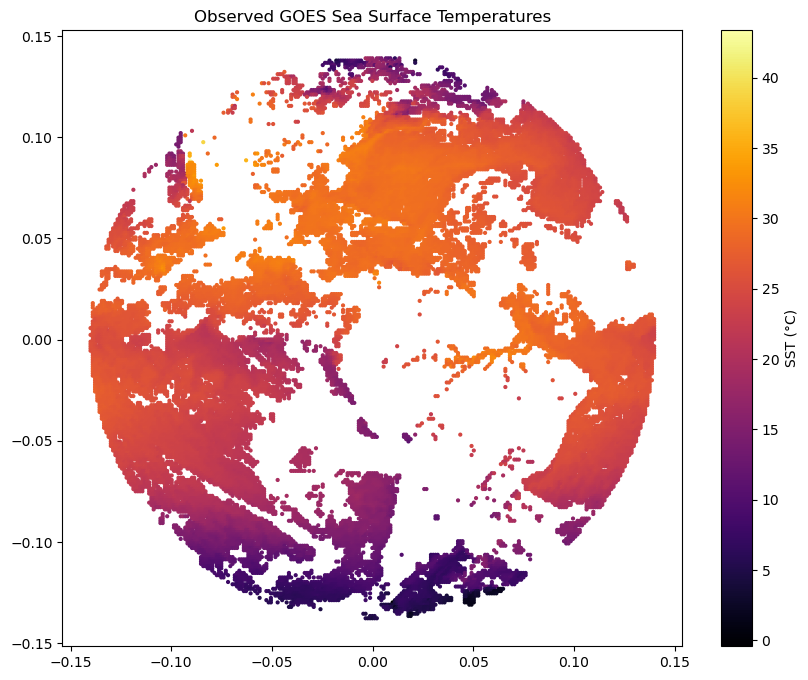

In [16]:
goes_grid = pd.read_csv("goes_sst_grid.csv")

plt.figure(figsize=(10,8))

plt.scatter(
    goes_grid["x"],
    goes_grid["y"],
    c=goes_grid["sst_c"],
    s=4,
    cmap="inferno"
)

plt.colorbar(label="SST (°C)")

plt.title("Observed GOES Sea Surface Temperatures")

plt.savefig(
    "goes_sst_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
import os
print(os.path.getsize("goes_sst_summary.csv"))

1


In [22]:
def process_one_goes_file(fs, file):
    with fs.open(file) as f:
        ds = xr.open_dataset(f, engine="h5netcdf")

        print(ds.data_vars)

        sst = ds["SST"]

        if "DQF" in ds:
            sst = sst.where(ds["DQF"] == 0)

        sst_c = sst - 273.15

        row = {
            "file": file,
            "time": pd.to_datetime(ds["t"].values).isoformat(),
            "mean_sst_c": float(sst_c.mean(skipna=True).values),
            "max_sst_c": float(sst_c.max(skipna=True).values),
            "min_sst_c": float(sst_c.min(skipna=True).values),
            "valid_pixels": int(sst_c.count().values)
        }

        return row


In [26]:
goes_summary = process_goes_days(
    year=2020,
    days=[210],
    max_files_per_day=1
)

goes_summary

Day 210: found 24 files
Processing: noaa-goes16/ABI-L2-SSTF/2020/210/00/OR_ABI-L2-SSTF-M6_G16_s20202100000205_e20202100059513_c20202100105456.nc
Data variables:
    SST                                                     (y, x) float32 118MB ...
    DQF                                                     (y, x) float32 118MB ...
    time_bounds                                             (number_of_time_bounds) datetime64[ns] 16B ...
    goes_imager_projection                                  int32 4B ...
    y_image_bounds                                          (number_of_image_bounds) float32 8B ...
    x_image_bounds                                          (number_of_image_bounds) float32 8B ...
    nominal_satellite_subpoint_lat                          float32 4B ...
    nominal_satellite_subpoint_lon                          float32 4B ...
    nominal_satellite_height                                float32 4B ...
    geospatial_lat_lon_extent                               floa

,file,time,mean_sst_c,max_sst_c,min_sst_c,valid_pixels
0,noaa-goes16/ABI-L2-SSTF/2020/210/00/OR_ABI-L2-...,2020-07-28T00:30:05.934142976,24.562283,43.388397,-0.578033,3925136


In [27]:
goes_summary.to_csv("goes_sst_summary.csv", index=False)

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import os

print("Summary size:", os.path.getsize("goes_sst_summary.csv"))
print("Grid size:", os.path.getsize("goes_sst_grid.csv"))

goes_summary = pd.read_csv("goes_sst_summary.csv")
goes_grid = pd.read_csv("goes_sst_grid.csv")

display(goes_summary.head())
display(goes_grid.head())

Summary size: 257
Grid size: 2726344


,file,time,mean_sst_c,max_sst_c,min_sst_c,valid_pixels
0,noaa-goes16/ABI-L2-SSTF/2020/210/00/OR_ABI-L2-...,2020-07-28T00:30:05.934142976,24.562283,43.388397,-0.578033,3925136


,y,x,t,y_image,x_image,retrieval_local_zenith_angle,quantitative_local_zenith_angle,retrieval_solar_zenith_angle,day_solar_zenith_angle,night_solar_zenith_angle,sst_c,time
0,0.138992,-0.003472,2020-07-28 00:30:05.934142976,0.0,0.0,90.0,67.0,180.0,85.0,95.0,19.169868,2020-07-28T00:30:05.934142976
1,0.138992,-0.002352,2020-07-28 00:30:05.934142976,0.0,0.0,90.0,67.0,180.0,85.0,95.0,18.347849,2020-07-28T00:30:05.934142976
2,0.138992,-0.001232,2020-07-28 00:30:05.934142976,0.0,0.0,90.0,67.0,180.0,85.0,95.0,17.967121,2020-07-28T00:30:05.934142976
3,0.138992,-0.000112,2020-07-28 00:30:05.934142976,0.0,0.0,90.0,67.0,180.0,85.0,95.0,17.531528,2020-07-28T00:30:05.934142976
4,0.138992,0.002128,2020-07-28 00:30:05.934142976,0.0,0.0,90.0,67.0,180.0,85.0,95.0,16.514603,2020-07-28T00:30:05.934142976


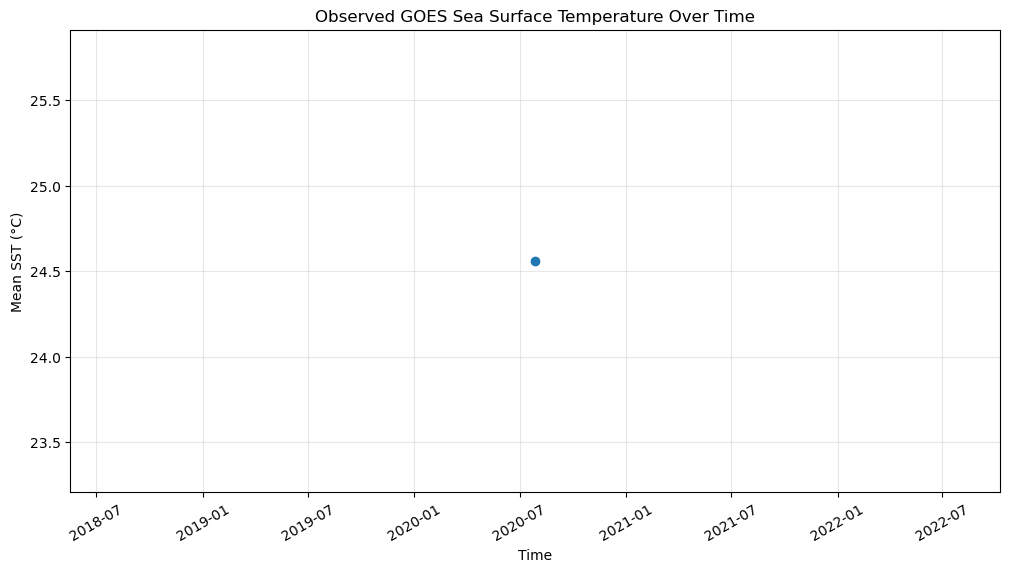

In [29]:
goes_summary["time"] = pd.to_datetime(goes_summary["time"])
goes_summary = goes_summary.sort_values("time")

plt.figure(figsize=(12, 6))

plt.plot(
    goes_summary["time"],
    goes_summary["mean_sst_c"],
    marker="o",
    linewidth=2
)

plt.title("Observed GOES Sea Surface Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Mean SST (°C)")
plt.grid(alpha=0.3)
plt.xticks(rotation=30)

plt.savefig("goes_sst_timeseries.png", dpi=300, bbox_inches="tight")
plt.show()

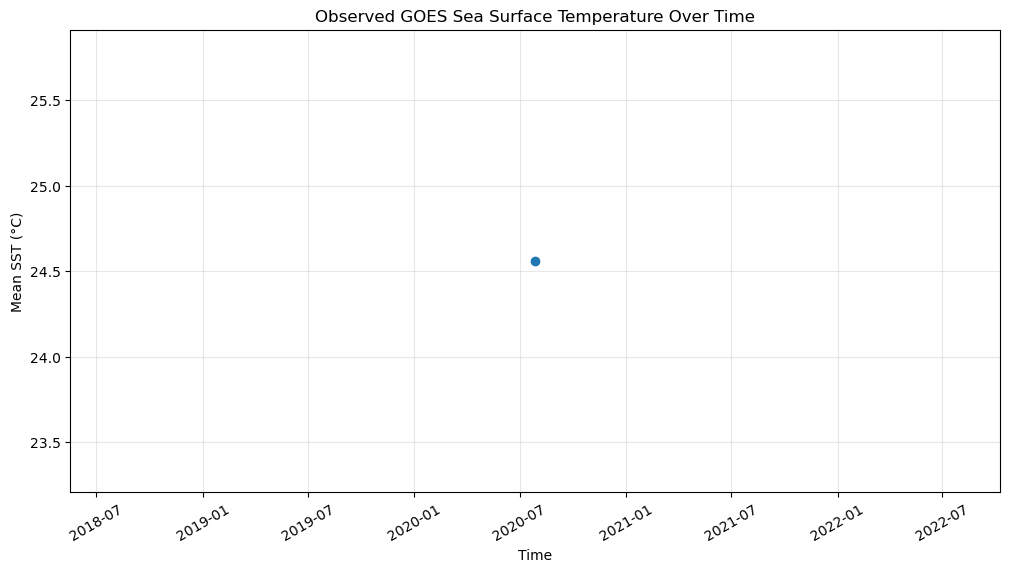

In [30]:
goes_summary["time"] = pd.to_datetime(goes_summary["time"])
goes_summary = goes_summary.sort_values("time")

plt.figure(figsize=(12, 6))

plt.plot(
    goes_summary["time"],
    goes_summary["mean_sst_c"],
    marker="o",
    linewidth=2
)

plt.title("Observed GOES Sea Surface Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Mean SST (°C)")
plt.grid(alpha=0.3)
plt.xticks(rotation=30)

plt.savefig("goes_sst_timeseries.png", dpi=300, bbox_inches="tight")
plt.show()

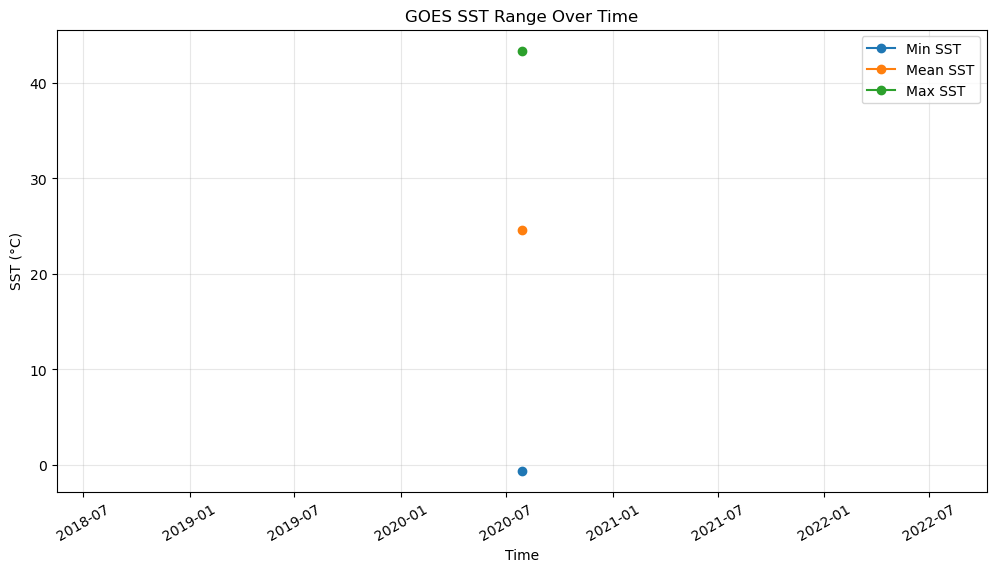

In [31]:
plt.figure(figsize=(12, 6))

plt.plot(goes_summary["time"], goes_summary["min_sst_c"], marker="o", label="Min SST")
plt.plot(goes_summary["time"], goes_summary["mean_sst_c"], marker="o", label="Mean SST")
plt.plot(goes_summary["time"], goes_summary["max_sst_c"], marker="o", label="Max SST")

plt.title("GOES SST Range Over Time")
plt.xlabel("Time")
plt.ylabel("SST (°C)")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=30)

plt.savefig("goes_sst_range.png", dpi=300, bbox_inches="tight")
plt.show()

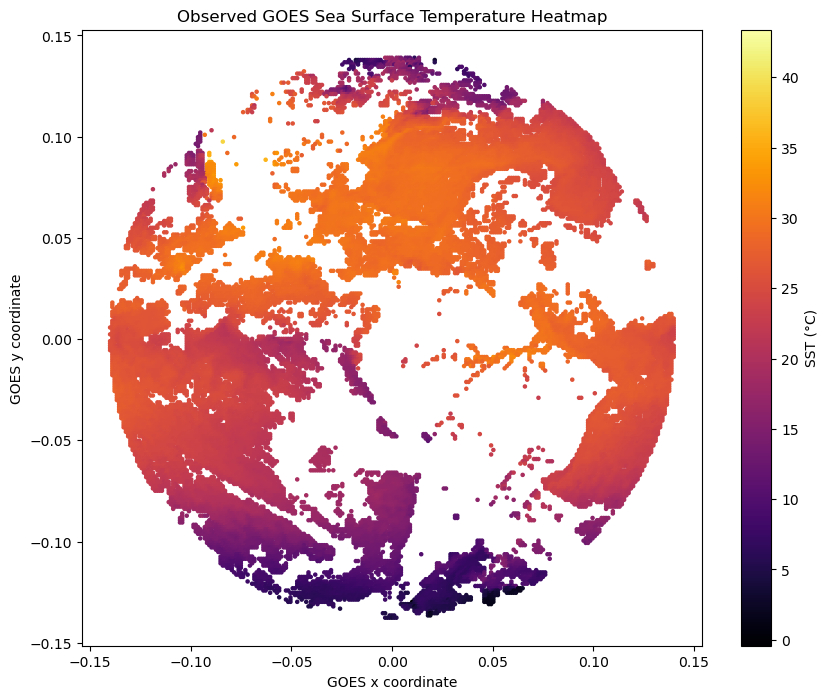

In [32]:
plt.figure(figsize=(10, 8))

plt.scatter(
    goes_grid["x"],
    goes_grid["y"],
    c=goes_grid["sst_c"],
    s=5,
    cmap="inferno"
)

plt.colorbar(label="SST (°C)")
plt.title("Observed GOES Sea Surface Temperature Heatmap")
plt.xlabel("GOES x coordinate")
plt.ylabel("GOES y coordinate")

plt.savefig("goes_sst_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

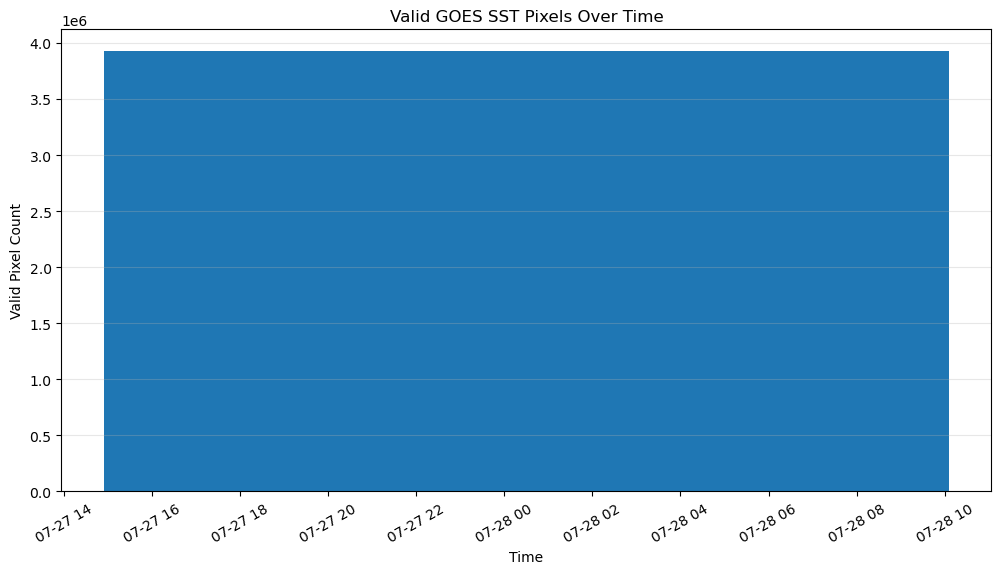

In [33]:
plt.figure(figsize=(12, 6))

plt.bar(
    goes_summary["time"],
    goes_summary["valid_pixels"]
)

plt.title("Valid GOES SST Pixels Over Time")
plt.xlabel("Time")
plt.ylabel("Valid Pixel Count")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.savefig("goes_valid_pixels.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
import pandas as pd
import xarray as xr
import s3fs
import numpy as np

fs = s3fs.S3FileSystem(anon=True)

def get_goes_files(year, day_of_year, product="ABI-L2-SSTF"):
    bucket = "noaa-goes16"
    syr = str(year).zfill(4)
    sjdy = str(day_of_year).zfill(3)
    return fs.glob(f"s3://{bucket}/{product}/{syr}/{sjdy}/*/*.nc")

def process_one_fast(file):
    with fs.open(file) as f:
        ds = xr.open_dataset(f, engine="h5netcdf")

        sst = ds["SST"]

        if "DQF" in ds:
            sst = sst.where(ds["DQF"] == 0)

        sst_c = sst - 273.15

        row = {
            "file": file,
            "time": pd.to_datetime(ds["t"].values).isoformat(),
            "mean_sst_c": float(sst_c.mean(skipna=True).values),
            "max_sst_c": float(sst_c.max(skipna=True).values),
            "min_sst_c": float(sst_c.min(skipna=True).values),
            "valid_pixels": int(sst_c.count().values)
        }

        ds.close()
        return row

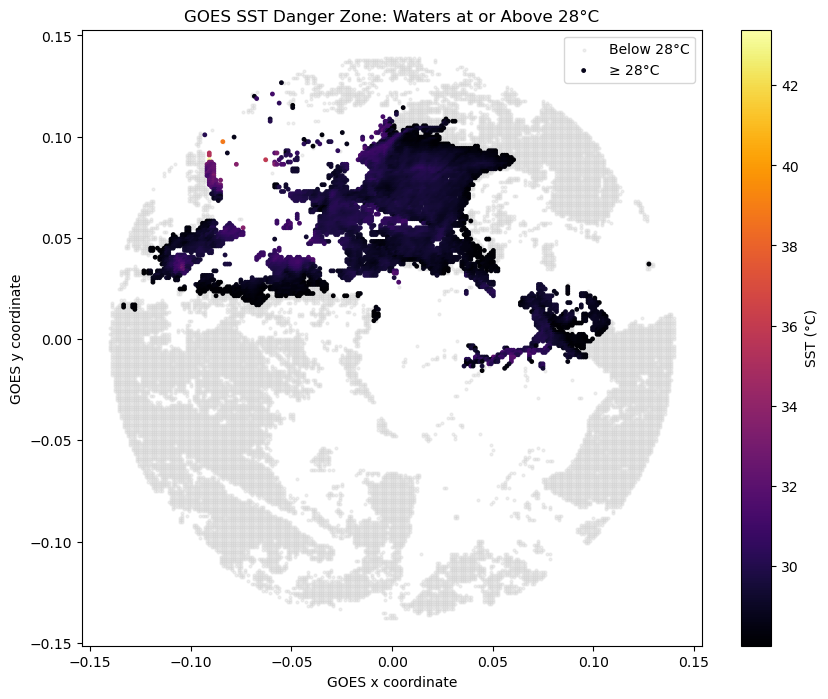

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

goes_grid = pd.read_csv("goes_sst_grid.csv")

threshold = 28

plt.figure(figsize=(10, 8))

plt.scatter(
    goes_grid["x"],
    goes_grid["y"],
    c="lightgray",
    s=4,
    alpha=0.35,
    label="Below 28°C"
)

danger = goes_grid[goes_grid["sst_c"] >= threshold]

plt.scatter(
    danger["x"],
    danger["y"],
    c=danger["sst_c"],
    s=6,
    cmap="inferno",
    label="≥ 28°C"
)

plt.colorbar(label="SST (°C)")
plt.title("GOES SST Danger Zone: Waters at or Above 28°C")
plt.xlabel("GOES x coordinate")
plt.ylabel("GOES y coordinate")
plt.legend()

plt.savefig("goes_danger_zone_map.png", dpi=300, bbox_inches="tight")
plt.show()

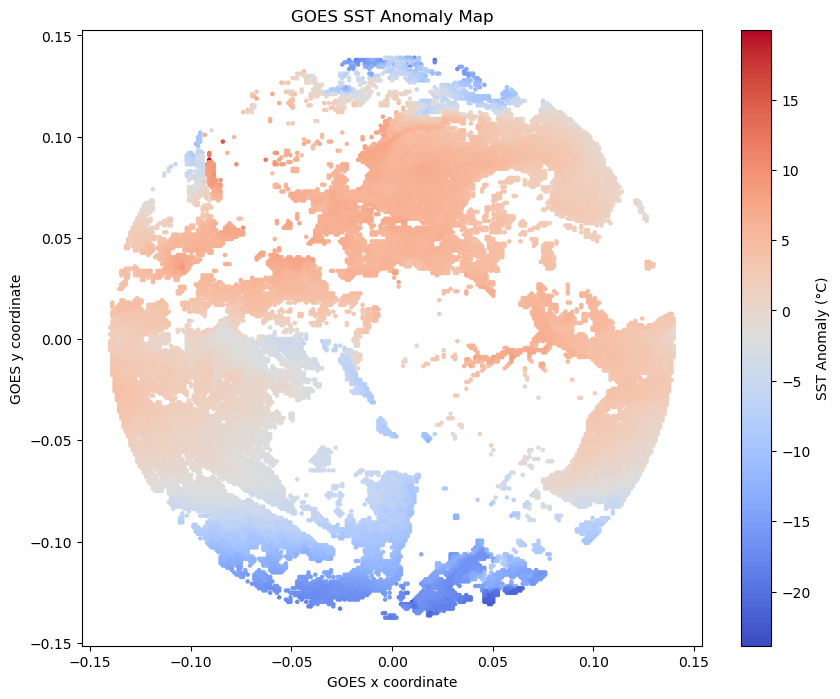

In [37]:
goes_grid["sst_anomaly_c"] = goes_grid["sst_c"] - goes_grid["sst_c"].mean()

plt.figure(figsize=(10, 8))

plt.scatter(
    goes_grid["x"],
    goes_grid["y"],
    c=goes_grid["sst_anomaly_c"],
    s=5,
    cmap="coolwarm"
)

plt.colorbar(label="SST Anomaly (°C)")
plt.title("GOES SST Anomaly Map")
plt.xlabel("GOES x coordinate")
plt.ylabel("GOES y coordinate")

plt.savefig("goes_sst_anomaly_map.png", dpi=300, bbox_inches="tight")
plt.show()

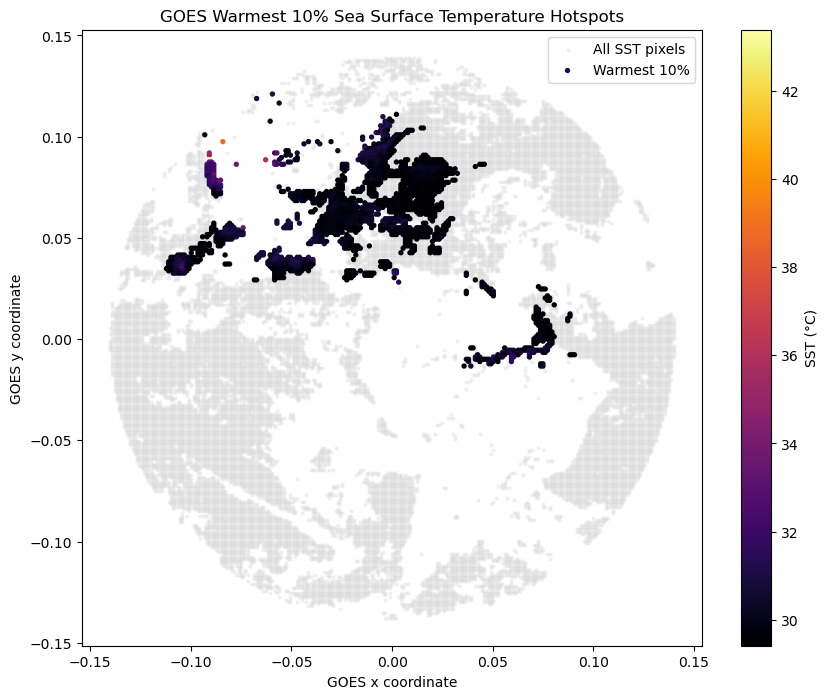

In [38]:
hotspot_cutoff = goes_grid["sst_c"].quantile(0.90)

hotspots = goes_grid[goes_grid["sst_c"] >= hotspot_cutoff]

plt.figure(figsize=(10, 8))

plt.scatter(
    goes_grid["x"],
    goes_grid["y"],
    c="lightgray",
    s=4,
    alpha=0.25,
    label="All SST pixels"
)

plt.scatter(
    hotspots["x"],
    hotspots["y"],
    c=hotspots["sst_c"],
    s=8,
    cmap="inferno",
    label="Warmest 10%"
)

plt.colorbar(label="SST (°C)")
plt.title("GOES Warmest 10% Sea Surface Temperature Hotspots")
plt.xlabel("GOES x coordinate")
plt.ylabel("GOES y coordinate")
plt.legend()

plt.savefig("goes_hotspot_map.png", dpi=300, bbox_inches="tight")
plt.show()